In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os

In [2]:
data = sio.loadmat(os.environ.get("DATASETS")+"/ECG_DATASET/Dataset3/WFDBRecords/01/010/JS00001.mat")
variables = data["val"]

In [3]:
ecg_all = np.array(variables)
ecg_01 = ecg_all[10, :]
ecg_02 = ecg_all[1, :]

lenSignal = ecg_all.shape[1]

fs = 500

time = np.arange(lenSignal)/fs

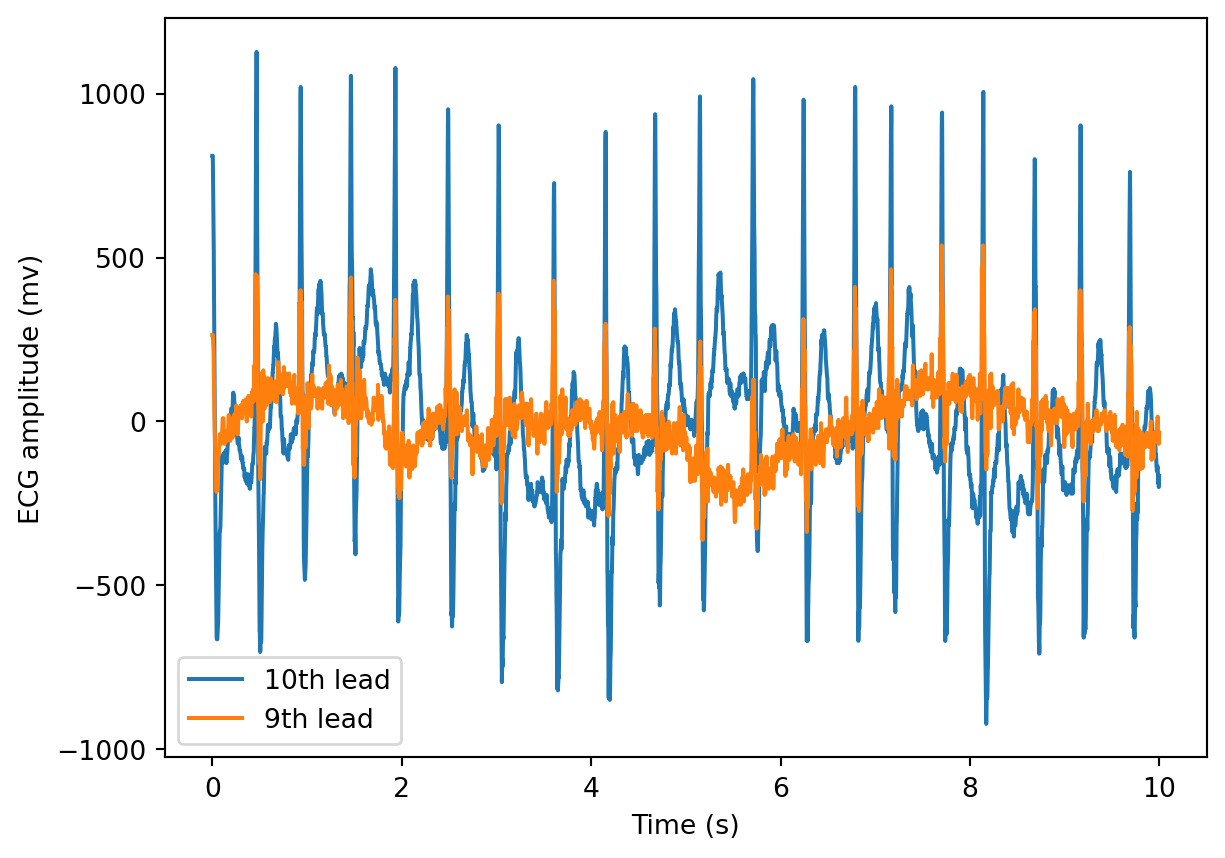

In [4]:
fig0001 = plt.figure()
plt.plot(time, ecg_01, label="10th lead")
plt.plot(time, ecg_02, label="9th lead")
plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude (mv)")
plt.legend()

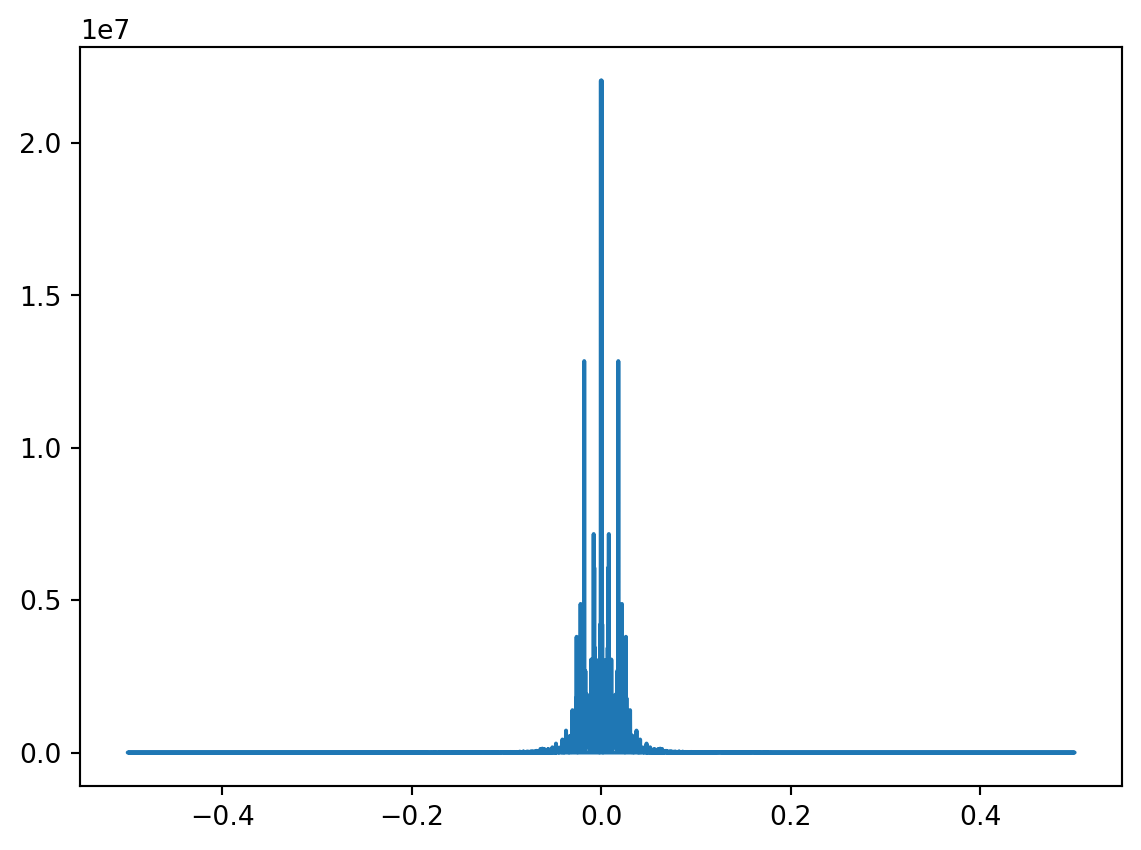

In [5]:
ecg_fft = np.fft.fft(ecg_01)
ecg_psd = np.real(ecg_fft*np.conj(ecg_fft)/len(ecg_01))
fig0002 = plt.figure()
plt.plot(np.fft.fftfreq(lenSignal), ecg_psd, )

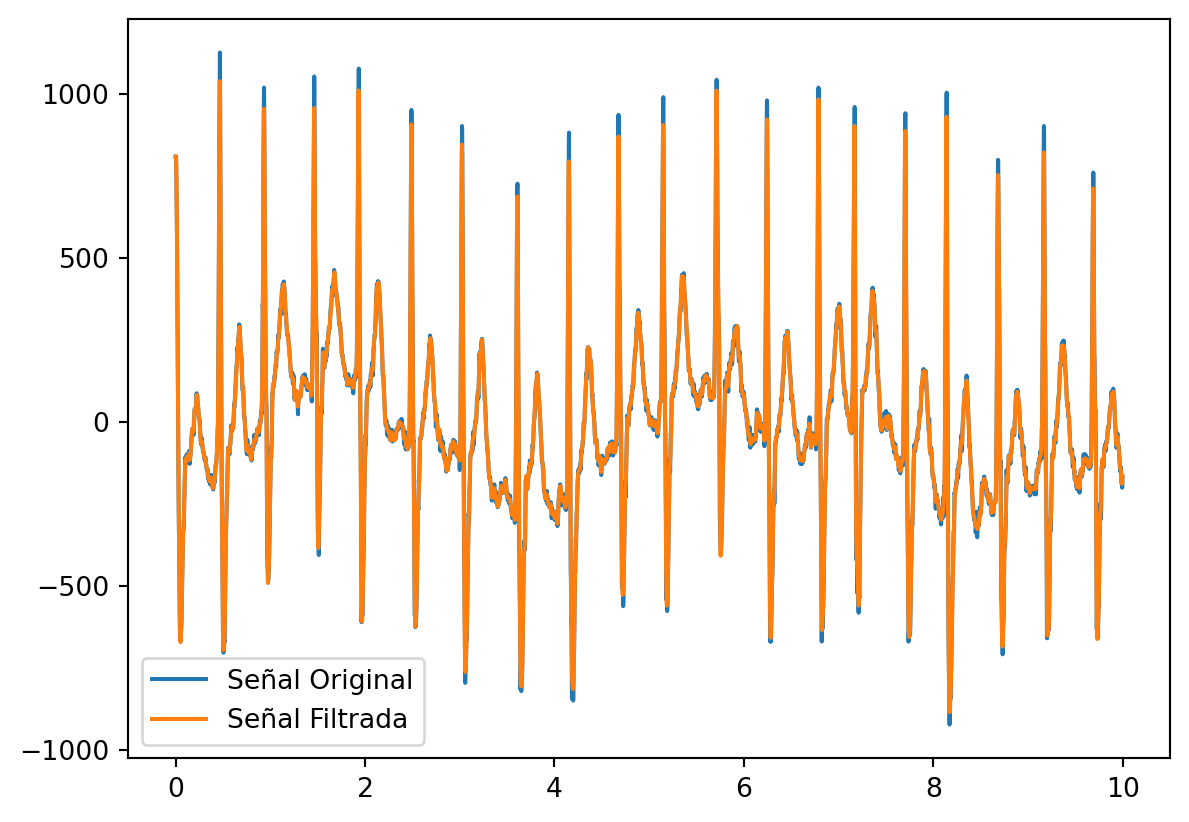

In [6]:
from scipy import signal

fcut = 50
wcut = fcut/(fs/2)

b, a = signal.butter(6, wcut, "low")
ecg_filt = signal.filtfilt(b,a, ecg_01)

fig0003 = plt.figure()
plt.plot(time, ecg_01, label="Señal Original")
plt.plot(time, ecg_filt, label="Señal Filtrada")
plt.legend()

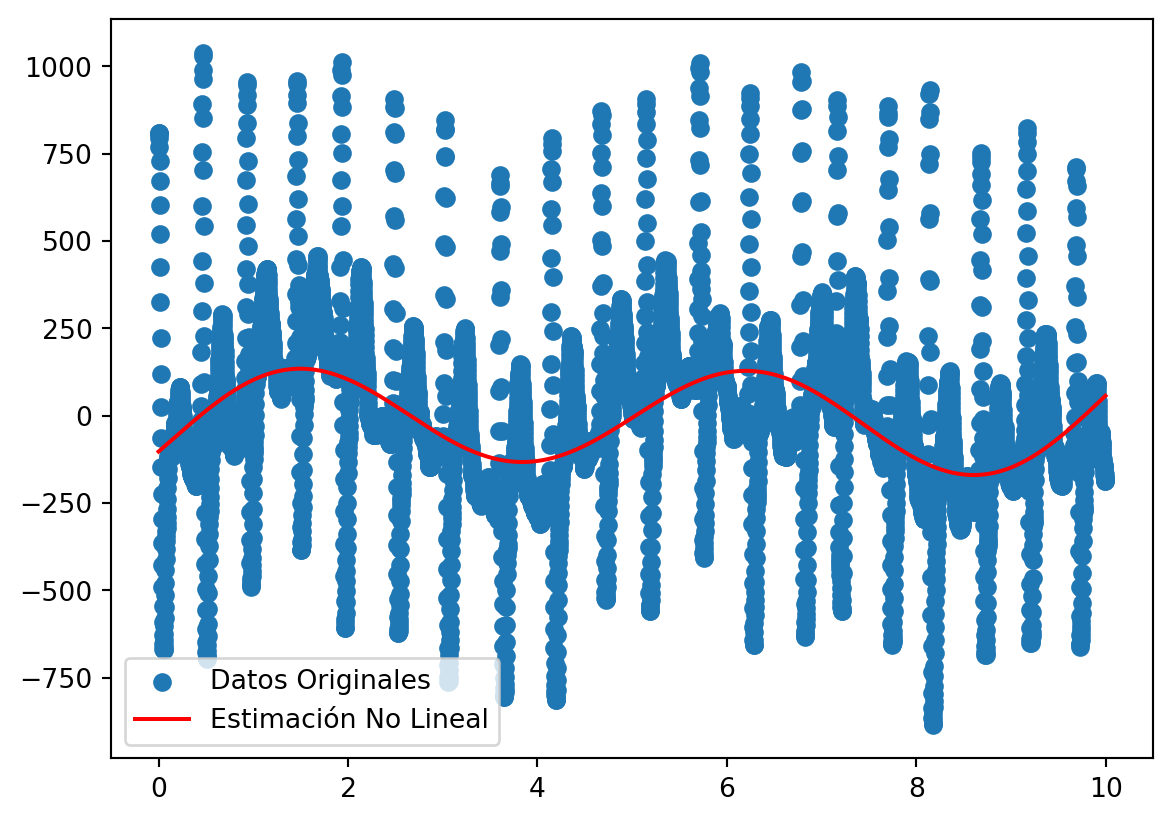

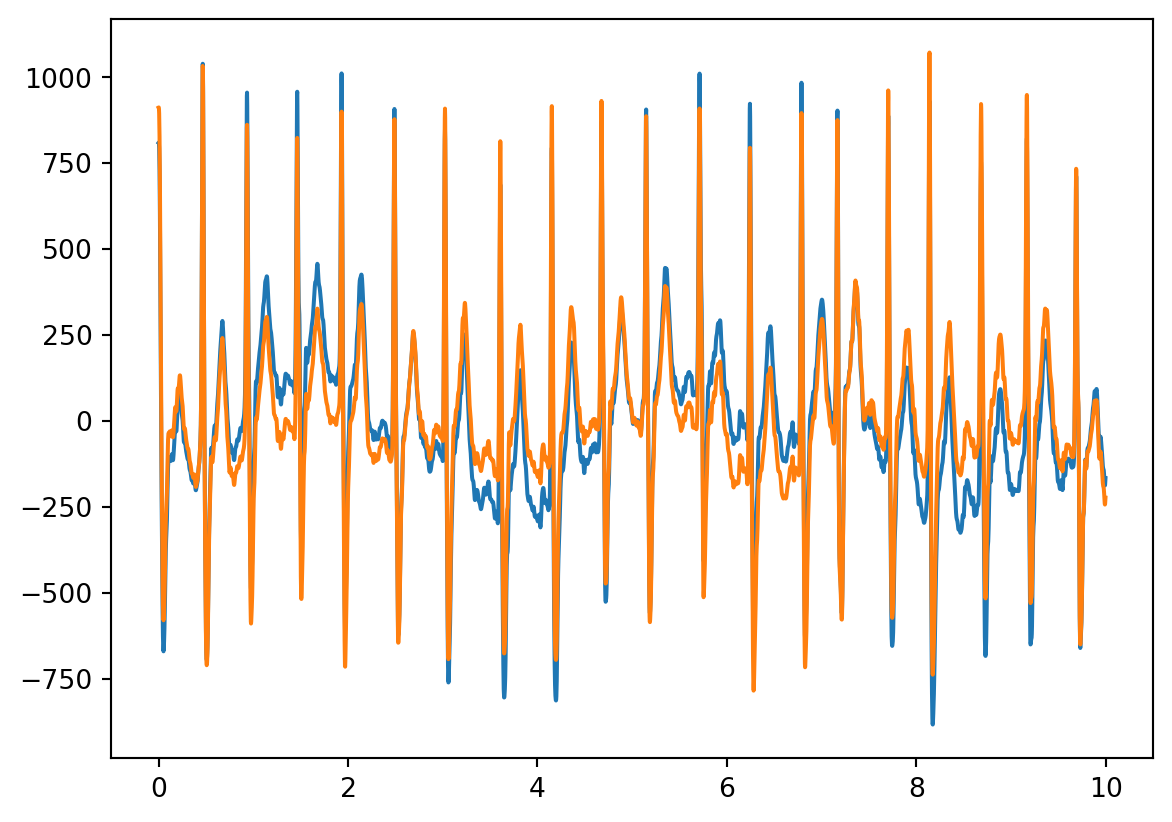

In [7]:
import statsmodels.api as sm
from scipy.optimize import curve_fit

def nonlinearfunction(x, p1, p2, p3, p4, p5, p6):
    return p1+ p2*x + p3*np.sin(p4*x) + p5*np.cos(p6*x)

popt, pcov = curve_fit(nonlinearfunction, time, ecg_01)

# Graficar los datos originales y la estimación LOESS
plt.scatter(time, ecg_filt, label='Datos Originales')
plt.plot(time, nonlinearfunction(time, *popt), color='red', label='Estimación No Lineal')
plt.legend()
plt.show()


ecg_filt_trend1 = ecg_filt-nonlinearfunction(time, *popt)
fig0005 = plt.figure()

plt.plot(time, ecg_filt)
plt.plot(time, ecg_filt_trend1)

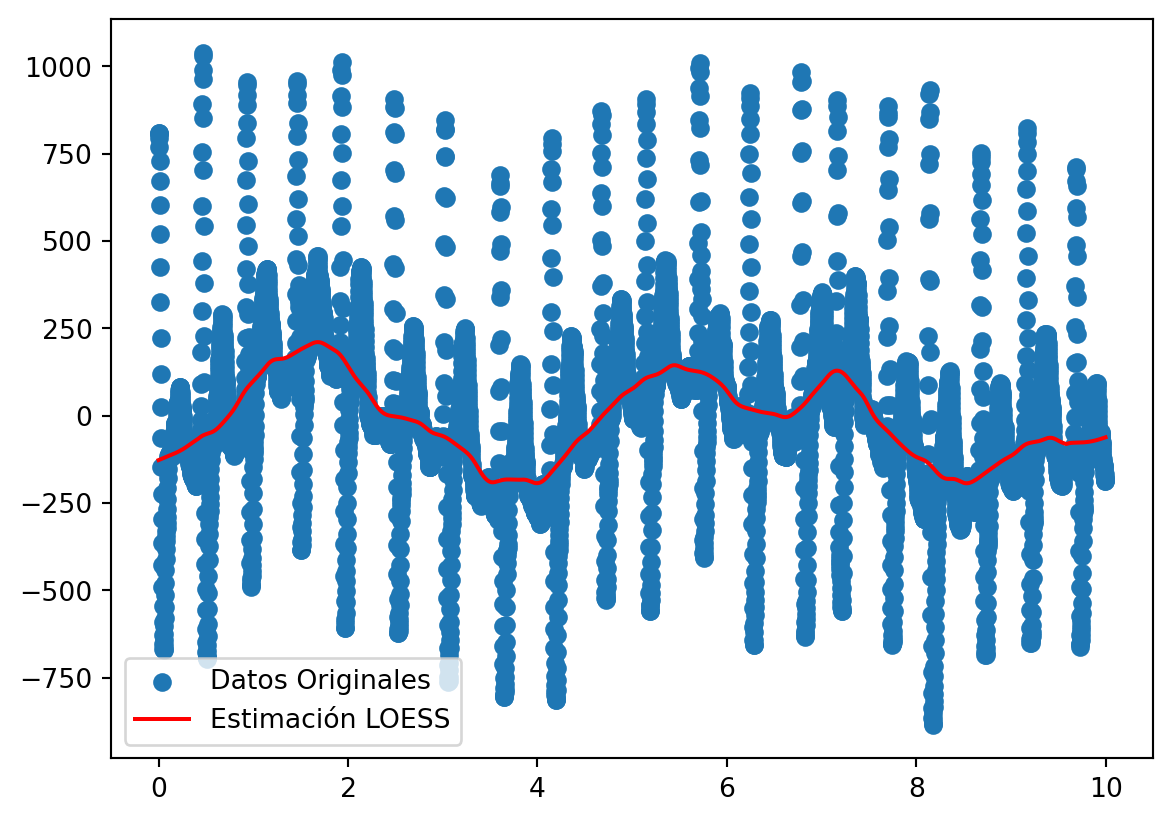

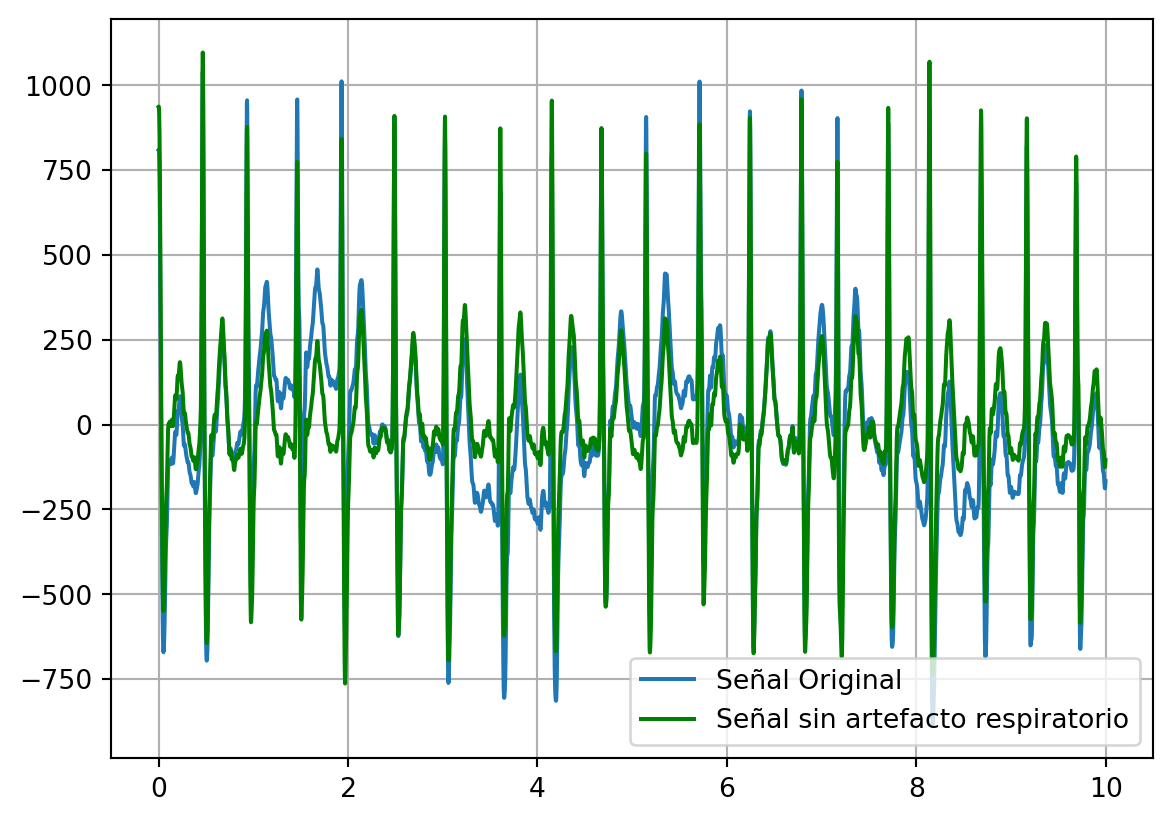

In [8]:
# Estimación LOESS
lowess = sm.nonparametric.lowess(ecg_filt, time, frac=1/12)

# Graficar los datos originales y la estimación LOESS
plt.scatter(time, ecg_filt, label='Datos Originales')
plt.plot(lowess[:, 0], lowess[:, 1], color='red', label='Estimación LOESS')
plt.legend()
plt.show()


ecg_filt_trend2 = ecg_filt-lowess[:, 1]
fig0004 = plt.figure()

plt.plot(time, ecg_filt, label="Señal Original")
plt.plot(time, ecg_filt_trend2, 'g', label="Señal sin artefacto respiratorio")
plt.legend()
plt.grid()

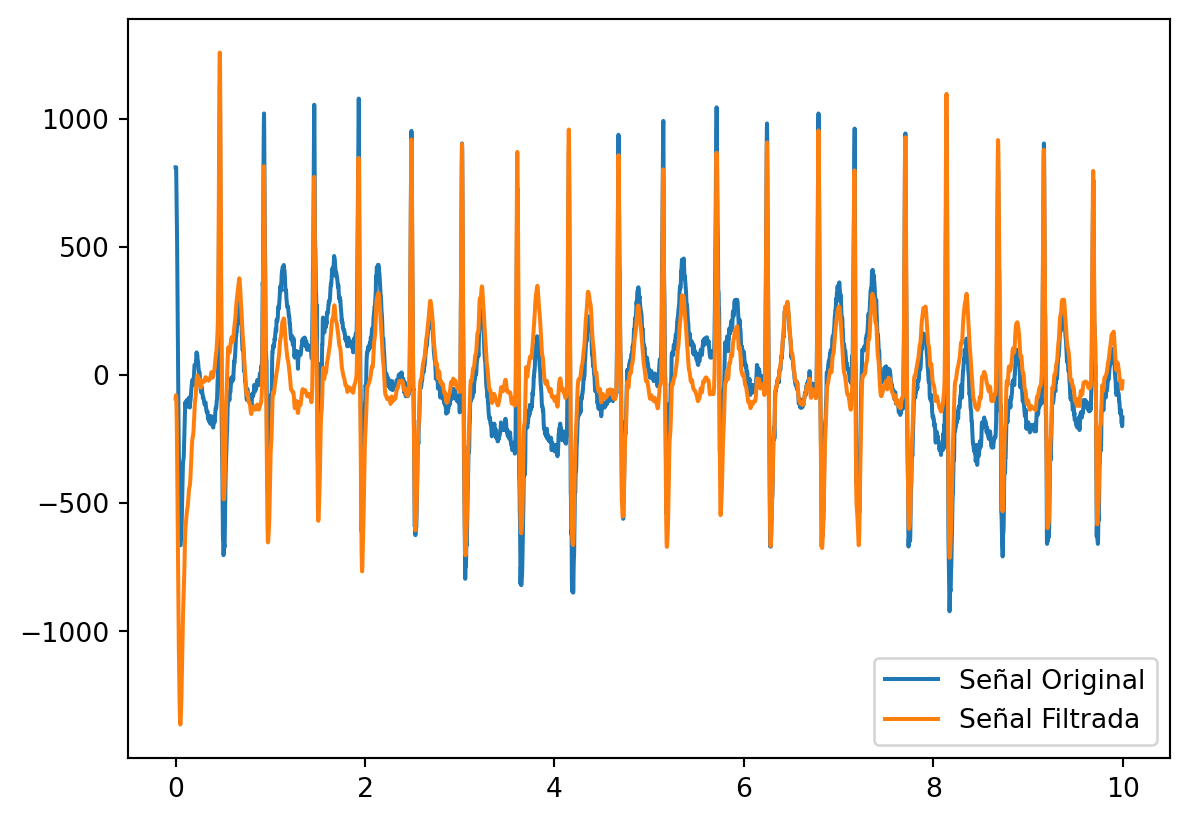

In [9]:
fcut1 = 50
fcut2 = 1
wcut1 = fcut1/(fs/2)
wcut2 = fcut2/(fs/2)

b, a = signal.butter(6, [wcut2, wcut1], "bandpass")
ecg_filt2 = signal.filtfilt(b,a, ecg_01)

fig0005 = plt.figure()
plt.plot(time, ecg_01, label="Señal Original")
plt.plot(time, ecg_filt2, label="Señal Filtrada")
plt.legend()

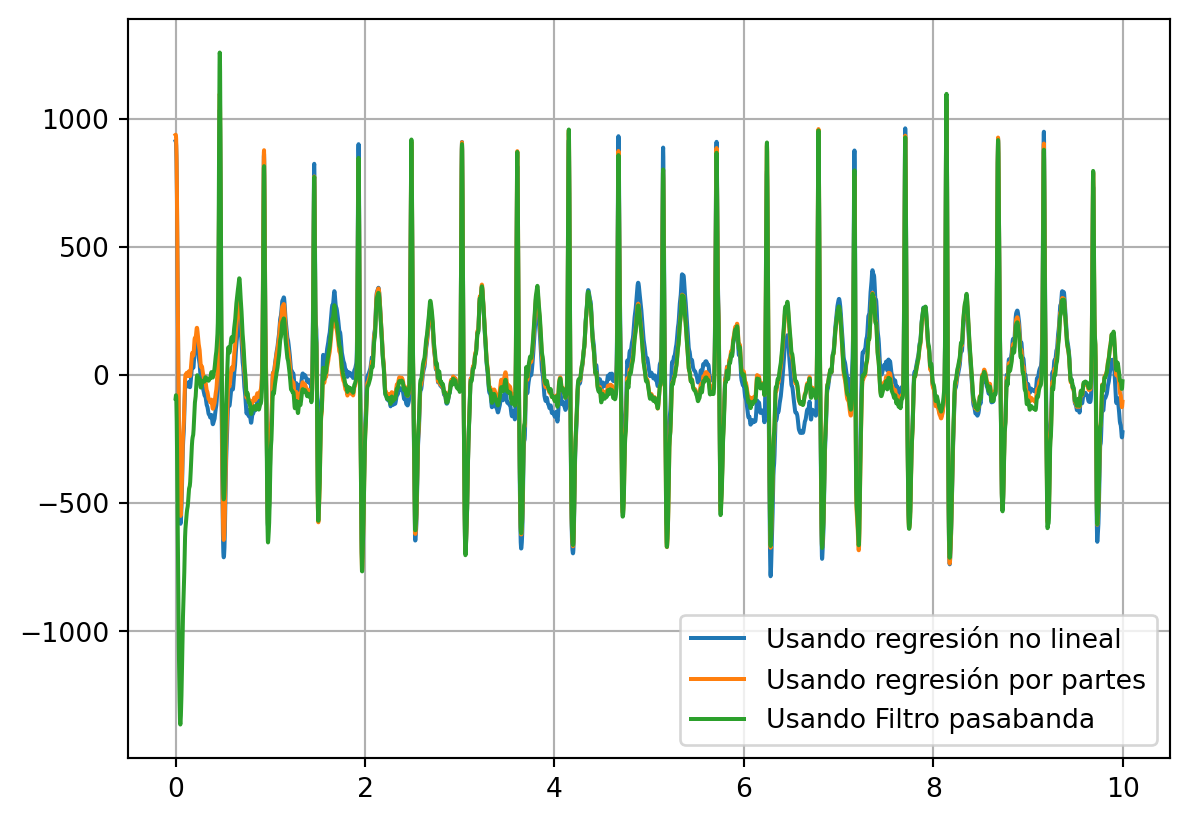

In [10]:
fig006 = plt.figure()
plt.plot(time, ecg_filt_trend1, label="Usando regresión no lineal")
plt.plot(time, ecg_filt_trend2, label="Usando regresión por partes")
plt.plot(time, ecg_filt2, label="Usando Filtro pasabanda")
plt.legend()
plt.grid()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5a60bdeb-81ed-4d05-bc32-035b1b133794' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>
